# Nestle Fundamentals Case Study

This case study analyzes a Nestle-like consumer staples company using synthetic, rounded financial data. It is designed for learning and should not be treated as investment advice.

Abbreviations used in this notebook:

- **COGS**: Cost of Goods Sold.
- **FCF**: Free Cash Flow.
- **CapEx**: Capital Expenditures.
- **ROIC**: Return on Invested Capital.
- **CHF**: Swiss franc, the currency used in the examples.

## 1. Intuition

Fundamental analysis asks whether a company is economically strong before asking whether the stock is cheap. For a mature consumer staples company, the most important questions are revenue resilience, margin stability, cash conversion, reinvestment needs, and balance-sheet risk.

## 2. Mathematics

Gross margin:

$$
Gross\ Margin = \frac{Revenue - COGS}{Revenue}
$$

Operating margin:

$$
Operating\ Margin = \frac{Operating\ Income}{Revenue}
$$

Free cash flow:

$$
FCF = Operating\ Cash\ Flow - CapEx
$$

FCF conversion:

$$
FCF\ Conversion = \frac{FCF}{Net\ Income}
$$

ROIC approximation:

$$
ROIC = \frac{Operating\ Income \times (1 - Tax\ Rate)}{Invested\ Capital}
$$

## 3. Implementation

We build a compact financial statement history and calculate the key quality metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

financials = pd.DataFrame({
    "year": [2020, 2021, 2022, 2023, 2024],
    "revenue": [84_300, 87_100, 94_400, 98_600, 102_000],
    "cogs": [42_800, 43_900, 48_200, 49_400, 50_500],
    "operating_income": [14_900, 15_600, 16_200, 17_000, 17_500],
    "net_income": [10_200, 10_900, 11_200, 11_700, 12_100],
    "operating_cash_flow": [14_100, 15_300, 16_000, 17_200, 18_000],
    "capex": [4_600, 4_800, 5_100, 5_400, 5_700],
    "invested_capital": [82_000, 84_500, 87_000, 90_500, 93_000],
    "net_debt": [33_000, 34_000, 35_500, 35_300, 35_000],
})

financials["gross_profit"] = financials["revenue"] - financials["cogs"]
financials["gross_margin"] = financials["gross_profit"] / financials["revenue"]
financials["operating_margin"] = financials["operating_income"] / financials["revenue"]
financials["fcf"] = financials["operating_cash_flow"] - financials["capex"]
financials["fcf_margin"] = financials["fcf"] / financials["revenue"]
financials["fcf_conversion"] = financials["fcf"] / financials["net_income"]
financials["roic"] = financials["operating_income"] * (1 - 0.21) / financials["invested_capital"]
financials

,year,revenue,cogs,operating_income,net_income,operating_cash_flow,capex,invested_capital,net_debt,gross_profit,gross_margin,operating_margin,fcf,fcf_margin,fcf_conversion,roic
0,2020,84300,42800,14900,10200,14100,4600,82000,33000,41500,0.492289,0.176750,9500,0.112693,0.931373,0.143549
1,2021,87100,43900,15600,10900,15300,4800,84500,34000,43200,0.495982,0.179104,10500,0.120551,0.963303,0.145846
2,2022,94400,48200,16200,11200,16000,5100,87000,35500,46200,0.489407,0.171610,10900,0.115466,0.973214,0.147103
3,2023,98600,49400,17000,11700,17200,5400,90500,35300,49200,0.498986,0.172414,11800,0.119675,1.008547,0.148398
4,2024,102000,50500,17500,12100,18000,5700,93000,35000,51500,0.504902,0.171569,12300,0.120588,1.016529,0.148656


In [2]:
latest = financials.iloc[-1]
first = financials.iloc[0]
summary = pd.Series({
    "revenue_cagr": (latest["revenue"] / first["revenue"]) ** (1 / (latest["year"] - first["year"])) - 1,
    "latest_gross_margin": latest["gross_margin"],
    "latest_operating_margin": latest["operating_margin"],
    "latest_fcf_margin": latest["fcf_margin"],
    "latest_fcf_conversion": latest["fcf_conversion"],
    "latest_roic": latest["roic"],
    "latest_net_debt": latest["net_debt"],
})
summary.to_frame("value")

,value
revenue_cagr,0.048801
latest_gross_margin,0.504902
latest_operating_margin,0.171569
latest_fcf_margin,0.120588
latest_fcf_conversion,1.016529
latest_roic,0.148656
latest_net_debt,35000.000000


## 4. Visualization

Fundamental charts should separate scale from quality: revenue and income show size; margins and cash conversion show economics.

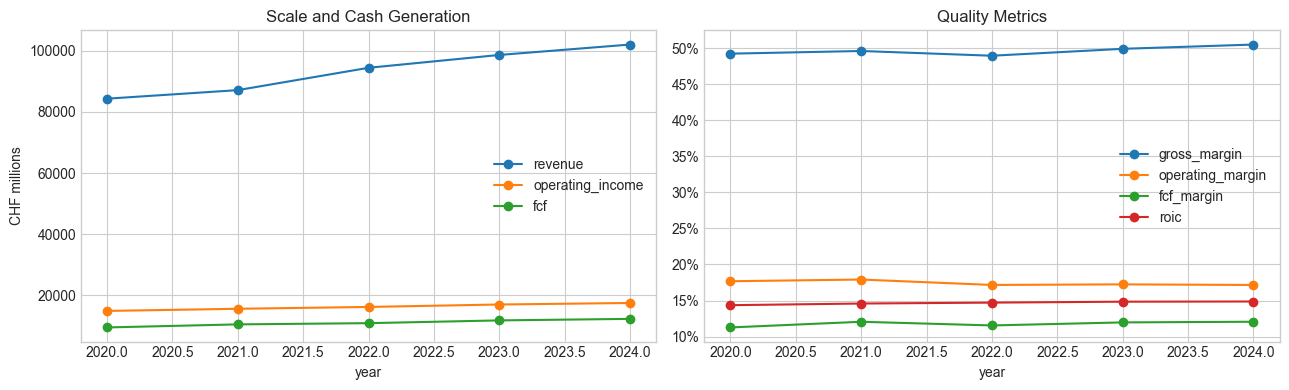

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
financials.plot(x="year", y=["revenue", "operating_income", "fcf"], marker="o", ax=axes[0])
axes[0].set_title("Scale and Cash Generation")
axes[0].set_ylabel("CHF millions")

financials.plot(x="year", y=["gross_margin", "operating_margin", "fcf_margin", "roic"], marker="o", ax=axes[1])
axes[1].set_title("Quality Metrics")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout(); plt.show()

## 5. Application

This company profile looks consistent with a mature defensive business: modest growth, stable margins, positive free cash flow, and strong cash conversion. The main valuation question is whether the market price already reflects that quality.

In [4]:
quality_flags = pd.Series({
    "stable_operating_margin": financials["operating_margin"].std() < 0.01,
    "positive_fcf_each_year": (financials["fcf"] > 0).all(),
    "fcf_conversion_above_80pct": latest["fcf_conversion"] > 0.80,
    "roic_above_10pct": latest["roic"] > 0.10,
})
quality_flags.to_frame("flag")

,flag
stable_operating_margin,True
positive_fcf_each_year,True
fcf_conversion_above_80pct,True
roic_above_10pct,True


## 6. Reflection

- Fundamentals frame business quality before valuation.
- Stable margins and cash conversion support confidence in a DCF.
- A high-quality company can still be a bad investment if overpaid.
- Synthetic case inputs should be replaced with sourced data in real research.

Questions to answer after running the notebook:

1. Is revenue growth stable enough for a mature-company DCF?
2. Does free cash flow conversion support earnings quality?
3. What metric creates the strongest quality argument?
4. What fundamental risk would you investigate next?